# Getting Started with RFInject

This notebook demonstrates how to use the `rfinject` toolkit to explore and analyze SAR data.

## Project Setup

This project uses `pdm` for dependency management. Before running this notebook, please ensure you have installed the dependencies by running the following command in your terminal from the project's root directory:

```bash
pdm install
```

This will set up a virtual environment with all the required packages. Make sure your Jupyter kernel is pointing to this environment.

## Autoreload

The following cell loads the `autoreload` extension. This is useful for development, as it automatically reloads modules before executing code. If you make changes to `.py` files in the `rfinject` library, they will be reflected here without needing to restart the kernel.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from typing import Dict, List, Any, Tuple, Optional
import matplotlib.pyplot as plt
from scipy.signal import welch
import zarr

from rfinject import (
    DEFAULT_HF_BUCKET_ID,
    download_hf_bucket_path,
    open_hf_bucket_zarr,
)
from rfinject.utils import *
from rfinject.viz import *

# Print runtime versions.
print("Python version:", sys.version)
print("Zarr version:", zarr.__version__)

scene_path = 's1a-iw-raw-s-hh-20240116t204634-20240116t204707-052137-064d52.zarr'
cache_dir = Path('outputs/notebook_cache')
artifact_dir = Path('outputs/notebook_artifacts')
artifact_dir.mkdir(parents=True, exist_ok=True)

# Mirror product metadata first so the full hierarchy can be inspected.
data = open_hf_bucket_zarr(
    DEFAULT_HF_BUCKET_ID,
    scene_path,
    local_dir=cache_dir,
    metadata_only=True,
)

# For this notebook we only need payload chunks for burst_0.
for relative_path in [
    f'{scene_path}/burst_0/echo',
    f'{scene_path}/burst_0/rfi',
]:
    download_hf_bucket_path(DEFAULT_HF_BUCKET_ID, relative_path, local_dir=cache_dir)

path = cache_dir / scene_path
data = zarr.open(path, mode='r')
print('Local mirror:', path)


Python version: 3.12.9 | packaged by conda-forge | (main, Mar  4 2025, 22:44:42) [Clang 18.1.8 ]
Zarr version: 3.1.5


Local mirror: outputs/notebook_cache/s1a-iw-raw-s-hh-20240116t204634-20240116t204707-052137-064d52.zarr


In [3]:
# Explore the complete structure
explore_zarr_structure(data)

Zarr Structure:
📁 burst_33/
  📄 echo: (1409, 23726) complex64
  📄 rfi: (15, 1409, 23726) complex64
📁 burst_3/
  📄 rfi: (15, 1409, 23726) complex64
  📄 echo: (1409, 23726) complex64
📁 burst_35/
  📄 echo: (398, 19656) complex64
  📄 rfi: (15, 398, 19656) complex64
📁 burst_4/
  📄 rfi: (15, 1548, 23996) complex64
  📄 echo: (1548, 23996) complex64
📁 burst_34/
  📄 rfi: (15, 1548, 23996) complex64
  📄 echo: (1548, 23996) complex64
📁 burst_32/
  📄 rfi: (15, 1410, 19656) complex64
  📄 echo: (1410, 19656) complex64
📁 burst_2/
  📄 rfi: (15, 1410, 19656) complex64
  📄 echo: (1410, 19656) complex64
📁 burst_5/
  📄 rfi: (15, 1410, 19656) complex64
  📄 echo: (1410, 19656) complex64
📁 burst_29/
  📄 rfi: (15, 1410, 19656) complex64
  📄 echo: (1410, 19656) complex64
📁 burst_16/
  📄 rfi: (15, 1548, 23996) complex64
  📄 echo: (1548, 23996) complex64
📁 burst_18/
  📄 rfi: (15, 1409, 23726) complex64
  📄 echo: (1409, 23726) complex64
📁 burst_11/
  📄 rfi: (15, 1410, 19656) complex64
  📄 echo: (1410, 19656) comp

In [4]:
# Get detailed information about all bursts
burst_info = get_burst_info(data)

print('📊 Burst Information Summary:')
print(f'Total number of bursts: {len(burst_info)}')
print(f"=" * 40)

for burst_name, info in list(burst_info.items())[:2]:
    print(f'🚀 {burst_name}:')
    print(f'  Total size: {info["total_size_mb"]:.1f} MB')
    
    for array_name, array_info in info['arrays'].items():
        print(f'  📄 {array_name}:')
        print(f'    Shape: {array_info["shape"]}')
        print(f'    Type: {array_info["dtype"]}')
        print(f'    Size: {array_info["size_mb"]:.1f} MB')
        if array_info['chunks']:
            print(f'    Chunks: {array_info["chunks"]}')
    print(f"=" * 40)
    print()

📊 Burst Information Summary:
Total number of bursts: 36
🚀 burst_35:
  Total size: 955.0 MB
  📄 rfi:
    Shape: (15, 398, 19656)
    Type: complex64
    Size: 895.3 MB
    Chunks: (2, 50, 2457)
  📄 echo:
    Shape: (398, 19656)
    Type: complex64
    Size: 59.7 MB
    Chunks: (50, 2457)

🚀 burst_4:
  Total size: 4534.4 MB
  📄 rfi:
    Shape: (15, 1548, 23996)
    Type: complex64
    Size: 4251.0 MB
    Chunks: (1, 194, 3000)
  📄 echo:
    Shape: (1548, 23996)
    Type: complex64
    Size: 283.4 MB
    Chunks: (97, 1500)



Accessing the data

In [7]:
# Example: Access echo data from burst_0
echo_array = access_array_data(data, 'burst_0', 'echo')
rfi_array = access_array_data(data, 'burst_0', 'rfi')
rfi_idx = 0  # We have 15 different RFIs encoded in channels, plot only the first one

print(f'📡 Echo array from burst_0:')
print(f'  Shape: {echo_array.shape}')
print(f'  Type: {echo_array.dtype}')
print(f'  Chunks: {echo_array.chunks}')

📡 Echo array from burst_0:
  Shape: (1259, 23726)
  Type: complex64
  Chunks: (79, 2966)


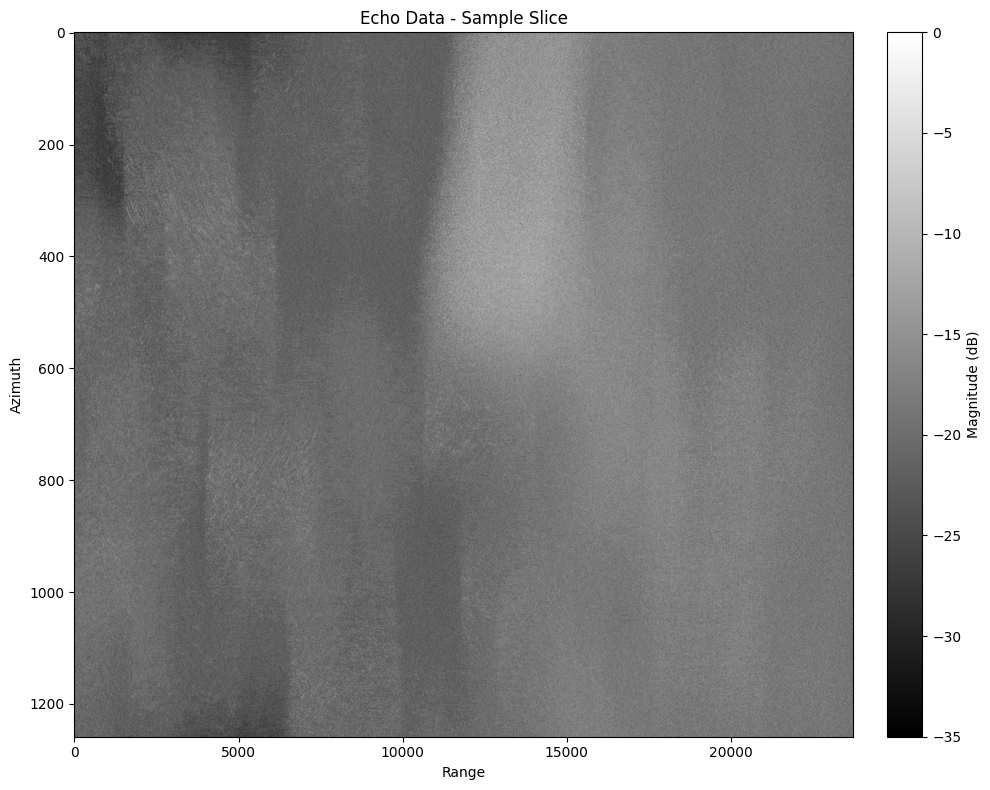

NameError: name 'rfi_idx' is not defined

In [10]:
# Plot bounded slices to keep notebook execution light enough for reproducible runs
plot_magnitude(echo_array, title='Echo Data - Sample Slice', vmin=-35, vmax=0, savefig=artifact_dir / 'echo_data_sample_slice.png')
plot_magnitude(rfi_array[rfi_idx], title='RFI Data - Sample Slice', vmin=-35, vmax=0, savefig=artifact_dir / 'rfi_data_sample_slice.png') # We have 15 different RFIs encoded in channels, plot only the first one

# Ancillary Data

In [ ]:
# Explore attributes on a representative subgroup to keep the notebook responsive
print('🏷️  Exploring Attributes for burst_0:')
all_attributes = explore_all_attributes(data['burst_0'])

if all_attributes:
    for idx, (path, attrs) in enumerate(all_attributes.items()):
        print(f'\n📍 {path}:')
        for key, value in attrs.items():
            print(f'  {key}')
            for idy, v in enumerate(value) if isinstance(value, list) else []:
                print(f'    - {list(v.keys())}' if isinstance(v, dict) else f'    - {v}')
                if idy >= 1:
                    print('    ...')
                    break
        if idx >= 1:
            print('  ...')
            break
else:
    print('No attributes found in this Zarr subgroup.')

🏷️  Exploring Attributes for burst_0:

📍 root:
  metadata
    - ['packet_version_number', 'packet_type', 'secondary_header_flag', 'pid', 'pcat', 'sequence_flags', 'packet_sequence_count', 'packet_data_length', 'coarse_time', 'fine_time', 'sync_marker', 'data_take_id', 'ecc_num', 'test_mode', 'rx_channel_id', 'instrument_configuration_id', 'data_word_index', 'space_packet_count', 'pri_count', 'error_flag', 'baq_mode', 'baq_block_length', 'range_decimation', 'rx_gain', 'tx_ramp_rate', 'tx_pulse_start_freq', 'tx_pulse_length', 'rank', 'pri', 'swst', 'swl', 'ssb_flag', 'polarization', 'temperature_compensation', 'elevation_beam_address', 'azimuth_beam_address', 'sas_test', 'cal_type', 'calibration_beam_address', 'cal_mode', 'tx_pulse_number', 'signal_type', 'swap', 'swath_number', 'number_of_quads', 'signal_type_name', 'data_take_hex', 'samples_per_line', 'polarization_name', 'temp_comp_name', 'sync_marker_valid', 'baq_mode_valid', 'packet_version_valid']
    - ['packet_version_number', 'p

In [ ]:
# Level 1: Per product attributes:
print('\n🏷️  Product-level Attributes:')
product_attributes = access_attributes(data)
ephemeris = product_attributes['ephemeris']
l0_name = product_attributes['l0_name']
ephemeris_df = pd.DataFrame(ephemeris)
print(f'l0_name: {l0_name}')
print(f'ephemeris shape: {ephemeris_df.shape}')
ephemeris_df.head()



🏷️  Product-level Attributes:
l0_name: S1A_IW_RAW__0SDH_20240116T204634_20240116T204707_052137_064D52_F263
ephemeris shape: (794, 59)


,x,y,z,vx,vy,vz,time_stamp,q0,q1,q2,...,tile12_efeh_temperature,tile12_efev_temperature,tile12_ta_temperature,tile13_efeh_temperature,tile13_efev_temperature,tile13_ta_temperature,tile14_efeh_temperature,tile14_efev_temperature,tile14_ta_temperature,tgu_temperature
0,1.706020e+06,-2.704724e+06,6.301904e+06,-5588.694336,3993.599121,3219.653076,23311492201840640,-0.287888,-0.178709,0.903463,...,87,81,85,91,83,88,87,78,77,89
1,1.706020e+06,-2.704724e+06,6.301904e+06,-5588.694336,3993.599121,3219.653076,23311492201840640,-0.287888,-0.178709,0.903463,...,87,81,85,91,83,88,87,78,77,89
2,1.706020e+06,-2.704724e+06,6.301904e+06,-5588.694336,3993.599121,3219.653076,23311492201840640,-0.287888,-0.178709,0.903463,...,87,81,85,91,83,88,87,78,77,89
3,1.706020e+06,-2.704724e+06,6.301904e+06,-5588.694336,3993.599121,3219.653076,23311492201840640,-0.287888,-0.178709,0.903463,...,87,81,85,91,83,88,87,78,77,89
4,1.706020e+06,-2.704724e+06,6.301904e+06,-5588.694336,3993.599121,3219.653076,23311492201840640,-0.287888,-0.178709,0.903463,...,87,81,85,91,83,88,87,78,77,89


In [11]:
# Level 2: Data per burst:
print('\n📡 Data Access Examples:')
echo_array = access_array_data(data, 'burst_0', 'echo')
# Level 2: Per burst ancillary:
attributes = access_attributes(data, 'burst_0')
metadata = attributes['metadata']
metadata_df = pd.DataFrame(metadata)
rfi_parameters = attributes['rfi_params']
rfi_parameters_df = pd.DataFrame(rfi_parameters)
print(f'metadata shape: {metadata_df.shape}')
print(f'rfi_parameters shape: {rfi_parameters_df.shape}')
metadata_df.head()


📡 Data Access Examples:
metadata shape: (1259, 53)
rfi_parameters shape: (15, 13)


,packet_version_number,packet_type,secondary_header_flag,pid,pcat,sequence_flags,packet_sequence_count,packet_data_length,coarse_time,fine_time,...,swath_number,number_of_quads,signal_type_name,data_take_hex,samples_per_line,polarization_name,temp_comp_name,sync_marker_valid,baq_mode_valid,packet_version_valid
0,0,0,True,65,12,3,3781,16997,1389473212,0.639915,...,10,11863,echo,0x0C9AA560,23726,H-V,disabled,True,True,True
1,0,0,True,65,12,3,3782,16965,1389473212,0.640495,...,10,11863,echo,0x0C9AA560,23726,H-V,disabled,True,True,True
2,0,0,True,65,12,3,3783,16941,1389473212,0.641075,...,10,11863,echo,0x0C9AA560,23726,H-V,disabled,True,True,True
3,0,0,True,65,12,3,3784,16977,1389473212,0.641670,...,10,11863,echo,0x0C9AA560,23726,H-V,disabled,True,True,True
4,0,0,True,65,12,3,3785,17005,1389473212,0.642250,...,10,11863,echo,0x0C9AA560,23726,H-V,disabled,True,True,True


# RFI

PSD input window: (128, 4096)


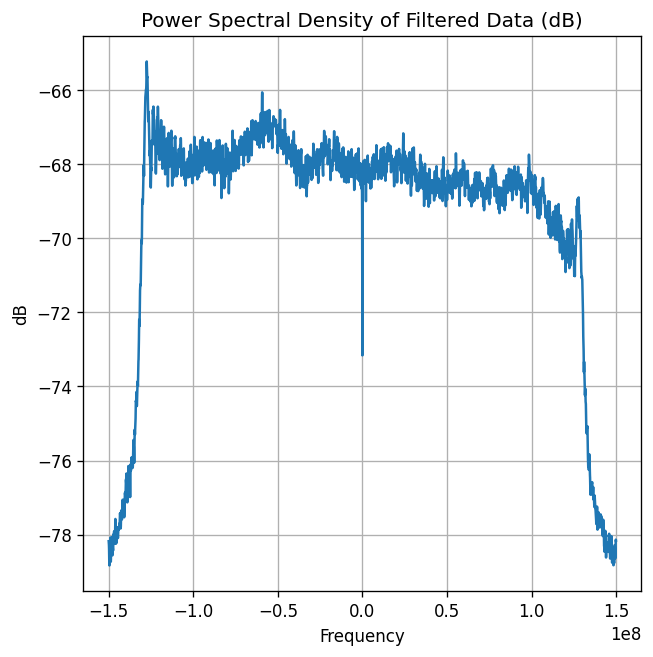

In [12]:
# Assuming sqdT is equivalent to filtered_data and RadPar.fs is the sampling frequency
sampling_frequency = 300e6  # 300 MHz

filtered_data = access_array_data(data, 'burst_0', 'echo')

# Compute the power spectral density on a representative subwindow so the notebook stays reproducible on laptops and CI
data_window = np.asarray(filtered_data[:128, :4096])
print(f'PSD input window: {data_window.shape}')
frequencies, psd = welch(data_window.reshape(-1), nperseg=2048, noverlap=1024, nfft=4096, fs=sampling_frequency, return_onesided=False)

# Shift the zero frequency component to the center
frequencies = np.fft.fftshift(frequencies)
psd = np.fft.fftshift(psd)

# Plot the power spectral density
plt.figure(figsize=(6, 6), dpi=120)
plt.plot(frequencies, 10 * np.log10(psd))
plt.title('Power Spectral Density of Filtered Data (dB)')
plt.xlabel('Frequency')
plt.ylabel('dB')
plt.gca()
plt.grid(True)
plt.show()

In [13]:
rfi_parameters_df.head()

,freqShift,fc,SIR_dB,bw,PRF,duty,Gain,Lambda,T,K,t,AffectedAz,AffectedRg
0,2.549169e+07,5.430492e+09,-6.470562,1.799656e+06,1192,0.189092,1.0,0.055205,0.000159,1.134470e+10,"[-7.931701019947535e-05, -7.930146903389529e-0...","[345, 1104]","[7967, 11618]"
1,-3.253719e+06,5.401747e+09,-8.964715,1.814020e+06,1058,0.171039,1.0,0.055499,0.000162,1.122104e+10,"[-8.08312013447603e-05, -8.081566017918023e-05...","[99, 1208]","[6846, 20576]"
2,-1.897160e+07,5.386029e+09,-19.091863,2.389713e+06,1488,0.333521,1.0,0.055661,0.000224,1.066166e+10,"[-0.000112070385570593, -0.0001120548444050129...","[84, 1184]","[957, 22677]"
3,1.709304e+07,5.422093e+09,-12.539714,1.233095e+06,1142,0.415674,1.0,0.055291,0.000364,3.387740e+09,"[-0.000181993667821788, -0.0001819781266562079...","[250, 698]","[3725, 17296]"
4,-7.540922e+06,5.397460e+09,-12.677303,2.035693e+06,1820,0.248688,1.0,0.055543,0.000137,1.489801e+10,"[-6.832098296493427e-05, -6.830544179935421e-0...","[145, 309]","[111, 7073]"


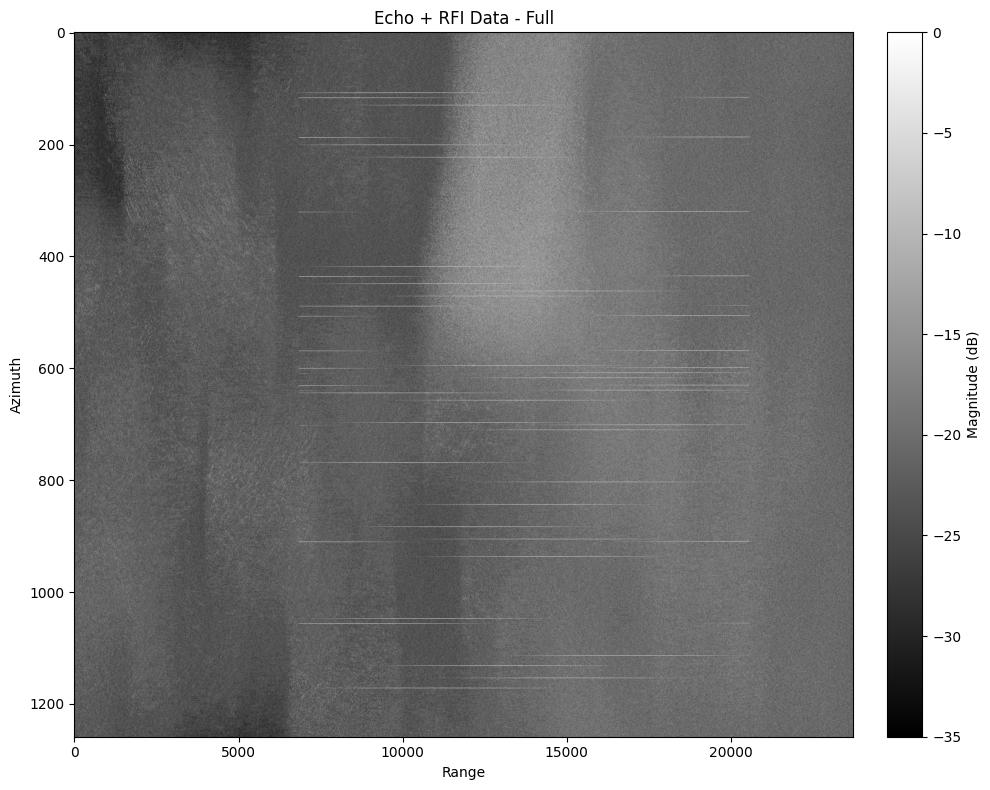

In [15]:
rfi_idx = 1
# Plot full Echo + RFI (no slicing)
echo_plus_rfi = rfi_array[rfi_idx] + echo_array
plot_magnitude(
    echo_plus_rfi,
    title='Echo + RFI Data - Full',
    vmin=-35,
    vmax=0,
    savefig=artifact_dir / 'echo_rfi_data_full.png'
)